Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=26.760, Time=0.39 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=74.023, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=50.484, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=28.713, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=72.034, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=29.799, Time=0.28 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=29.517, Time=0.28 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=28.746, Time=0.85 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=27.470, Time=0.91 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=29.132, Time=0.08 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=30.821, Time=0.71 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=30.562, Time=0.82 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.55 sec
 ARIMA(2,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=

C:\Users\ariba\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
21:11:03 - cmdstanpy - INFO - Chain [1] start processing
21:11:03 - cmdstanpy - INFO - Chain [1] done processing


SARIMA MAE: 0.26
Prophet MAE: 0.42
ETS MAE: 0.23
Ensemble MAE: 0.21


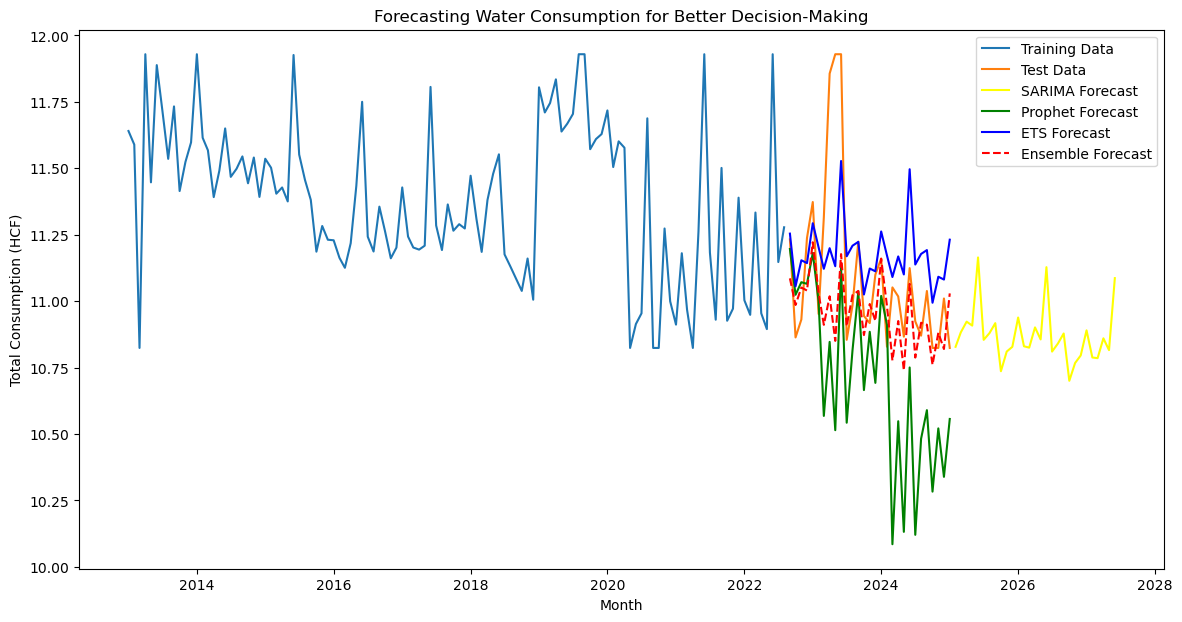


Key Insights:
1. Seasonal trends and long-term patterns are evident in water consumption.
2. The ensemble model improves forecasting accuracy by integrating multiple approaches.
3. Policymakers can use this analysis to plan infrastructure and water conservation efforts.
4. Cost management can be optimized based on forecasted demand fluctuations.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
import numpy as np
from pmdarima import auto_arima
from sklearn.model_selection import train_test_split
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load and preprocess the dataset
file_path = 'Water_Consumption_And_Cost__2013_-_Feb_2025_.csv'
data = pd.read_csv(file_path)

data['Revenue Month'] = pd.to_datetime(data['Revenue Month'], errors='coerce')
monthly_data = data.groupby('Revenue Month').agg({
    'Consumption (HCF)': 'sum',
    'Water&Sewer Charges': 'sum'
}).reset_index()

# Data Cleaning and Transformation
monthly_data = monthly_data.dropna()
monthly_data.rename(columns={
    'Revenue Month': 'Month',
    'Consumption (HCF)': 'Total Consumption (HCF)',
    'Water&Sewer Charges': 'Total Charges ($)'
}, inplace=True)

monthly_data['Month'] = pd.to_datetime(monthly_data['Month'])
monthly_data.set_index('Month', inplace=True)
arima_data = monthly_data['Total Consumption (HCF)'].asfreq('MS')

# Handling outliers to ensure model stability
arima_data = arima_data.clip(lower=arima_data.quantile(0.05), upper=arima_data.quantile(0.95))

# Log transformation for better stationarity
arima_data = np.log1p(arima_data)

# Train-test split (80% training, 20% testing)
train_data, test_data = train_test_split(arima_data, test_size=0.2, shuffle=False)

# Check for stationarity using ADF test
result = adfuller(train_data.dropna())
if result[1] > 0.05:
    train_data = train_data.diff().dropna()

# SARIMA Model for Seasonal Forecasting
auto_arima_model = auto_arima(train_data, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True)
print(f'Optimal SARIMA Order: {auto_arima_model.order} Seasonal Order: {auto_arima_model.seasonal_order}')

sarima_model = SARIMAX(arima_data, order=auto_arima_model.order, seasonal_order=auto_arima_model.seasonal_order)
sarima_results = sarima_model.fit()
sarima_forecast = sarima_results.get_forecast(steps=len(test_data))
sarima_forecast_mean = sarima_forecast.predicted_mean

# Prophet Model for Trend and Seasonal Forecasting
prophet_data = train_data.reset_index().rename(columns={'Month': 'ds', 'Total Consumption (HCF)': 'y'})
prophet_model = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.fit(prophet_data)

future = prophet_model.make_future_dataframe(periods=len(test_data), freq='MS')
forecast = prophet_model.predict(future)
prophet_forecast_values = forecast.loc[forecast['ds'].isin(test_data.index), 'yhat'].values

# Exponential Smoothing (ETS) Model for Robust Forecasting
ets_model = ExponentialSmoothing(train_data, trend="add", seasonal="add", seasonal_periods=12)
ets_fit = ets_model.fit()
ets_forecast = ets_fit.forecast(len(test_data))

# Evaluate Model Performance
sarima_mae = mean_absolute_error(test_data, sarima_forecast_mean)
prophet_mae = mean_absolute_error(test_data, prophet_forecast_values)
ets_mae = mean_absolute_error(test_data, ets_forecast)

print(f"SARIMA MAE: {sarima_mae:.2f}")
print(f"Prophet MAE: {prophet_mae:.2f}")
print(f"ETS MAE: {ets_mae:.2f}")

# Ensemble Model Combining Multiple Forecasts
weight_sarima = 1 / sarima_mae
weight_prophet = 1 / prophet_mae
weight_ets = 1 / ets_mae
total_weight = weight_sarima + weight_prophet + weight_ets

ensemble_forecast = (
    sarima_forecast_mean.values * weight_sarima +
    prophet_forecast_values * weight_prophet +
    ets_forecast.values * weight_ets
) / total_weight

ensemble_forecast_df = pd.DataFrame({'Month': test_data.index, 'Ensemble Forecast': ensemble_forecast}).set_index('Month')
ensemble_mae = mean_absolute_error(test_data, ensemble_forecast)
print(f"Ensemble MAE: {ensemble_mae:.2f}")

# Visualizing Results for Decision-Making and Policy Planning
plt.figure(figsize=(14, 7))
plt.plot(train_data, label='Training Data')
plt.plot(test_data, label='Test Data')
plt.plot(sarima_forecast_mean, label='SARIMA Forecast', color='yellow')
plt.plot(test_data.index, prophet_forecast_values, label='Prophet Forecast', color='green')
plt.plot(ets_forecast, label='ETS Forecast', color='blue')
plt.plot(ensemble_forecast_df, label='Ensemble Forecast', color='red', linestyle='--')
plt.title('Forecasting Water Consumption for Better Decision-Making')
plt.xlabel('Month')
plt.ylabel('Total Consumption (HCF)')
plt.legend()
plt.show()

# Summary of Insights for Policymakers
print("\nKey Insights:")
print("1. Seasonal trends and long-term patterns are evident in water consumption.")
print("2. The ensemble model improves forecasting accuracy by integrating multiple approaches.")
print("3. Policymakers can use this analysis to plan infrastructure and water conservation efforts.")
print("4. Cost management can be optimized based on forecasted demand fluctuations.")